## Aufgabe: Golf

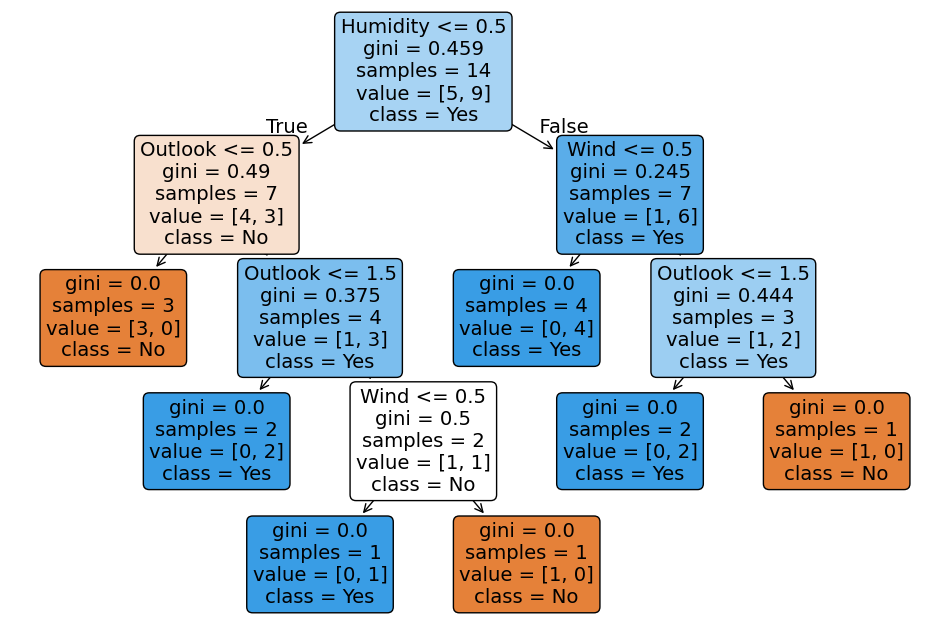

In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

column_names = ['Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayGolf']

# 1) CSV korrekt einlesen (Header aus Datei verwenden)
df = pd.read_csv("golf_data.csv")


df.columns = column_names


# 3) Mapping
outlook_map = {'Sunny': 0, 'Overcast': 1, 'Rainy': 2}
temp_map    = {'Hot': 0, 'Mild': 1, 'Cool': 2}
hum_map     = {'High': 0, 'Normal': 1}
wind_map    = {'Weak': 0, 'Strong': 1}
play_map    = {'No': 0, 'Yes': 1}

df['Outlook']     = df['Outlook'].map(outlook_map)
df['Temperature'] = df['Temperature'].map(temp_map)
df['Humidity']    = df['Humidity'].map(hum_map)
df['Wind']        = df['Wind'].map(wind_map)
df['PlayGolf']    = df['PlayGolf'].map(play_map)


# 5) Features und Zielvariable
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['PlayGolf']


# 6) Entscheidungsbaum
clf = DecisionTreeClassifier(
    criterion='gini',
    random_state=0,
)
clf.fit(X, y)

# 7) Visualisieren
plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=['Outlook', 'Temperature', 'Humidity', 'Wind'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.show()


## Aufgabe: Wine

In [9]:
#Daten laden und analysieren

from sklearn.datasets import load_wine

wine = load_wine()

# Features und Zielvariable als DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Daten anzeigen
print(df.head())
print("\nFeature-Namen:", wine.feature_names)
print("Zielklassen:", wine.target_names)
print(df.describe())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [23]:
#Trainings- und Testdaten aufteilen

from sklearn.model_selection import train_test_split

X = df[wine.feature_names]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


In [24]:
#Entscheidungsbaum-Klassifikator erstellen

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(
    criterion='gini',
    random_state=0,
)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Genauigkeit des Modells: 0.9629629629629629

Confusion Matrix:
 [[17  1  0]
 [ 1 20  0]
 [ 0  0 15]]


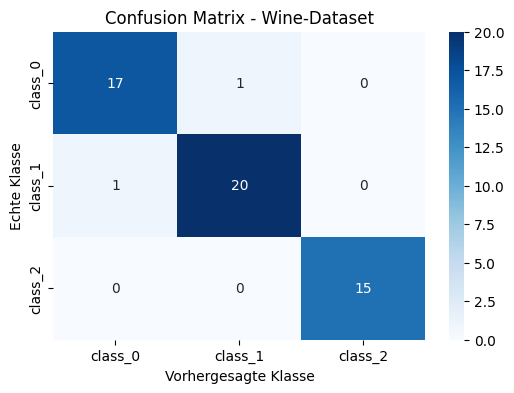

In [26]:
#Modellbewertung

from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#Vorhersagen
y_pred = clf.predict(X_test)

#Genauigkeit
acc = accuracy_score(y_test, y_pred)
print("Genauigkeit des Modells:", acc)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

#Visualisierung
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Echte Klasse')
plt.title('Confusion Matrix - Wine-Dataset')
plt.show()

## Aufgabe: California

In [27]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Dataset laden
data = fetch_california_housing()

# In DataFrame umwandeln
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target  # Zielvariable

print(df.head())
print(df.describe())
print(df.info())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.3333

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(X_train.shape, X_test.shape)


(14448, 8) (6192, 8)


In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Modell erstellen
model = DecisionTreeRegressor(random_state=42)

# Trainieren
model.fit(X_train, y_train)

# Vorhersagen
y_pred = model.predict(X_test)

# Bewertung
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)


R2 Score: 0.5991451236265484
Mean Squared Error: 0.526138102652923


In [34]:
from sklearn.model_selection import cross_val_score

model = DecisionTreeRegressor(random_state=42)

# 5-fold Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")

print("CV R2 Scores:", -cv_scores)
print("Durchschnitt R2:", -cv_scores.mean())
print("Std-Abweichung:", cv_scores.std())


CV R2 Scores: [0.81086528 0.73157388 0.77900631 0.90901644 0.85030349]
Durchschnitt R2: 0.8161530811099176
Std-Abweichung: 0.06058273307573604
